In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

sns.set()

## Construyendo una red neuronal

### Perceptron

Para crear el perceptron creamos una clase llamada **perceptron** que tiene como padre a **torch.nn.Module**. En su *init()* definimos a las capas:

- torch.nn.Sequential: Es un contenedor que nos permite ir apilando las capas que queremos de nuestra red. Este contenedor ademas se ocupa de conectas a las capas
- torch.nn.Linear: Es la capa que tiene los pesos de la entrada. En PyTorch, esa capa hay que especificarla, para que quede claro que es lineal (recordar w1x1 + x2x2 +...)
- torch.nn.Sigmoid: Es la capa de función de activación que usamos (Sigmoide)

In [43]:
class perceptron(torch.nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.layers = torch.nn.Sequential(
            torch.nn.Linear(input_size, output_size),
            torch.nn.Sigmoid()
        )
        
    #Define a la parte de predicción
    def forward(self, x):

        # Pasamos por el perceptron
        y_prob = self.layers(x)

        return y_prob
    
    def digital_out(self, x):

        y_prob = self.layers(x)

        return torch.heaviside((y_prob * 2) - 1, values=torch.tensor(0.))

In [44]:
# Entrenos al perceptron para que pueda reproducir a la función AND de tres variables
X_array = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 1],
    [0, 1, 0, 0, 1, 0, 1, 1],
    [0, 1, 1, 0, 1, 1, 1, 1],
    [1, 0, 0, 1, 0, 0, 1, 0],
    [1, 0, 1, 1, 0, 1, 1, 0],
    [1, 1, 0, 1, 1, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1]])

X = torch.from_numpy(X_array)
X = X.to(torch.float32)

y = torch.zeros((8, 1))
y[-1] = 1

In [45]:
# Creamos el perceptron de ocho entradas y una salida
net = perceptron(8, 1)
# Usamos como función de error a Entropía Cruzada Binaria, recomendada para clasificación
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

# Creamos una lista que mida el error en el loop
errors = list()

# Realizamos la iteración
for epoch in range(1000):

    ## Para cada uno de los datos del dataset
    #values = np.random.permutation(X.shape[0])
    #for i in values:
    # Limpiamos los gradientes
    optimizer.zero_grad()

    # Obtenemos todas las predicciones
    outputs = net(X)

    # Calculamos el error
    # ce = -[y_i * log(f(x_i)) + (1-y_i) * log(1-f(x_i))]
    loss = criterion(outputs, y)

    # Propagamos el error
    loss.backward()

    # Optimizamos los parametros
    optimizer.step()

    errors.append(loss.item())

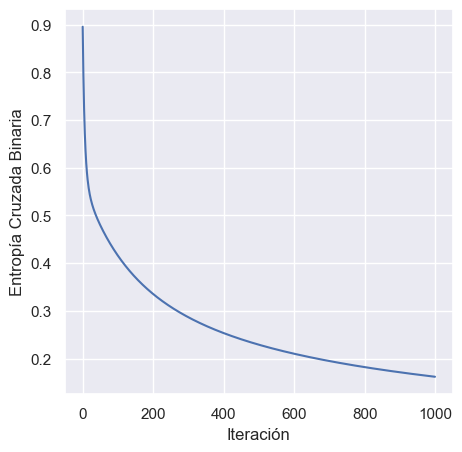

In [46]:
fig, ax = plt.subplots(figsize=(5,5))

ax.plot(errors)
ax.set_ylabel("Entropía Cruzada Binaria")
ax.set_xlabel("Iteración")
plt.show()

In [47]:
# Probemos a la red
test_1 = net.digital_out(torch.tensor([0., 0., 0., 0., 0., 0., 0., 0.]))
test_2 = net.digital_out(torch.tensor([1., 1., 1., 1., 1., 1., 1., 1.]))

print(f"Si la entrada es 0, 0, 0, 0, 0, 0, 0, 0, la salida es: {test_1.item()}")
print(f"Si la entrada es 1, 1, 1, 1, 1, 1, 1, 1, la salida es: {test_2.item()}")

Si la entrada es 0, 0, 0, 0, 0, 0, 0, 0, la salida es: 0.0
Si la entrada es 1, 1, 1, 1, 1, 1, 1, 1, la salida es: 1.0


In [48]:
# Cargar dataset
df = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_final.csv")
test_df = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_final_test.csv")


# Suponiendo que tenés un DataFrame df con la columna "Arrest_tag"
df_majority = df[df['Arrest_tag'] == 0]
df_minority = df[df['Arrest_tag'] == 1]

# Tomamos el mismo número de casos de la mayoría que de la minoría
df_majority_downsampled = df_majority.sample(
    n=len(df_minority), 
    random_state=42
)

# Combinamos ambas
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Mezclamos para no quedar con bloques homogéneos
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


"""
X = df_balanced.drop(["Arrest_tag"], axis=1)
y = df_balanced["Arrest_tag"]
"""

X = df.drop(["Arrest_tag"], axis=1)
y = df["Arrest_tag"]

X_test = test_df.drop(["Arrest_tag"], axis=1)
y_test = test_df["Arrest_tag"]

print(f"Shape del dataset: {df_balanced.shape}")
print(f"\nColumnas: {list(df_balanced.columns)}")

Shape del dataset: (55666, 9)

Columnas: ['IUCR_freq', 'Primary_Type_freq', 'Y Coordinate_standardized', 'X Coordinate_standardized', 'Distance Crime To Police Station_standardized', 'Location_Description_freq', 'Day Time_Night', 'Crime_District_freq', 'Arrest_tag']


In [49]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


X = df_balanced.drop(["Arrest_tag"], axis=1)
y = df_balanced["Arrest_tag"]

X_test = test_df.drop(["Arrest_tag"], axis=1)
y_test = test_df["Arrest_tag"]

X = X.values.astype(float)
y = y.values.astype(float)

X_test = X_test.values.astype(float)
y_test = y_test.values.astype(float)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, stratify=y)

# Convertimos en tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# Creamos usando DataLoader los sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [50]:
class BinaryNetwork(torch.nn.Module):
    """
    Red neuronal para clasificación binaria.

    Esta red neuronal consiste en múltiples capas totalmente conectadas con normalización por lotes
    y funciones de activación ReLU. La capa de salida utiliza una función de activación sigmoide
    para producir probabilidades de clasificación binaria.

    Args:
        input_size (int): El número de características de entrada.
    """
    def __init__(self, input_size):
        """
        Inicializa el modelo BinaryNetwork.

        Args:
            input_size (int): El número de características de entrada.
        """
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.BatchNorm1d(input_size),
            torch.nn.Linear(input_size, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1)
        )
        
    def forward(self, x):
        """
        Paso hacia adelante a través de la red.
        Args:
            x (torch.Tensor): Tensor de entrada de forma (batch_size, input_size).
        Returns:
            torch.Tensor: Tensor de salida conteniendo probabilidades de clasificación binaria.
        """
        x = self.layers(x)
        return torch.sigmoid(x)  # Escalamos los valores entre 0 y 1

In [51]:
# Inicialización del modelo, función de pérdida y optimizador
input_size = 8 # número de características
model = BinaryNetwork(input_size)

loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [52]:
# Bucle de entrenamiento
epochs = 450
max_patience = 5
patience = 0
patience_alpha = 0.001
best_val_loss = np.inf
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(1, epochs + 1):
    #  Entrenamiento
    model.train()  # Establecer el modelo en modo de entrenamiento
    train_loss = 0.0
    for features, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(features)
        loss = loss_fn(outputs, targets.unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * features.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validación
    model.eval()  # Establecer el modelo en modo de evaluación
    val_loss = 0.0
    val_preds = []
    val_targets = []
    with torch.no_grad():
        for features, targets in val_loader:
            outputs = model(features)
            loss = loss_fn(outputs, targets.unsqueeze(1))
            val_loss += loss.item() * features.size(0)
            val_preds.extend(outputs.round().squeeze().tolist())
            val_targets.extend(targets.tolist())
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    # Calcula la precisión de la validación
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)
    
    # Print estadísticas de entrenamiento/validación
    print(f'Época: {epoch}/{epochs}, Costo de Entrenamiento: {train_loss:.4f}, '
          f'Costo de Validación: {val_loss:.4f}, Exactitud en Validación: {val_accuracy:.4f}')
    
    # Callback early stopping
    if val_loss < best_val_loss*(1-patience_alpha):
        best_val_loss = val_loss
        patience = 0
    else:
        print(f"Validation loss not improved this epoch. Increasing patience counter.")
        patience += 1
        if patience >= max_patience:
            print(f"Max number of iterations without improvement reached. Stopping training.")
            break

Época: 1/450, Costo de Entrenamiento: 0.6746, Costo de Validación: 0.6491, Exactitud en Validación: 0.6433
Época: 2/450, Costo de Entrenamiento: 0.6453, Costo de Validación: 0.6369, Exactitud en Validación: 0.6490
Época: 3/450, Costo de Entrenamiento: 0.6391, Costo de Validación: 0.6322, Exactitud en Validación: 0.6495
Época: 4/450, Costo de Entrenamiento: 0.6344, Costo de Validación: 0.6284, Exactitud en Validación: 0.6483
Época: 5/450, Costo de Entrenamiento: 0.6310, Costo de Validación: 0.6254, Exactitud en Validación: 0.6497
Época: 6/450, Costo de Entrenamiento: 0.6276, Costo de Validación: 0.6228, Exactitud en Validación: 0.6528
Época: 7/450, Costo de Entrenamiento: 0.6254, Costo de Validación: 0.6204, Exactitud en Validación: 0.6544
Época: 8/450, Costo de Entrenamiento: 0.6229, Costo de Validación: 0.6176, Exactitud en Validación: 0.6544
Época: 9/450, Costo de Entrenamiento: 0.6213, Costo de Validación: 0.6157, Exactitud en Validación: 0.6544
Época: 10/450, Costo de Entrenamiento

In [56]:
# Evaluamos el modelo
y_pred_list = []
y_pred_proba_list = []
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        y_test_pred = model(X)
        y_pred_tag = torch.round(y_test_pred)
        y_pred_list.append(y_pred_tag)
        y_pred_proba_list.append(y_test_pred)

# Convertimos a la salida en un solo tensor
y_pred_tensor = torch.cat(y_pred_list).squeeze()
y_pred_proba_tensor = torch.cat(y_pred_proba_list).squeeze()

In [57]:
from sklearn.metrics import f1_score, accuracy_score

print(f"El porcentaje de exactitud es de:{accuracy_score(y_test, y_pred_tensor)*100: .0f}%")
print(f"F1-score de testeo fue: {f1_score(y_test, y_pred_tensor)}")

El porcentaje de exactitud es de: 71%
F1-score de testeo fue: 0.42404121350887236


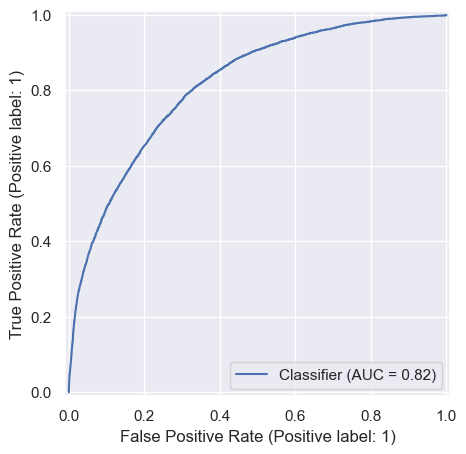

In [58]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(5,5))
svc_disp = RocCurveDisplay.from_predictions(y_test, y_pred_proba_tensor, ax=ax)

plt.show();